Rendering Panopticon ⇌ Synopticon GIF...
Displaying Awareness Topology Loop...



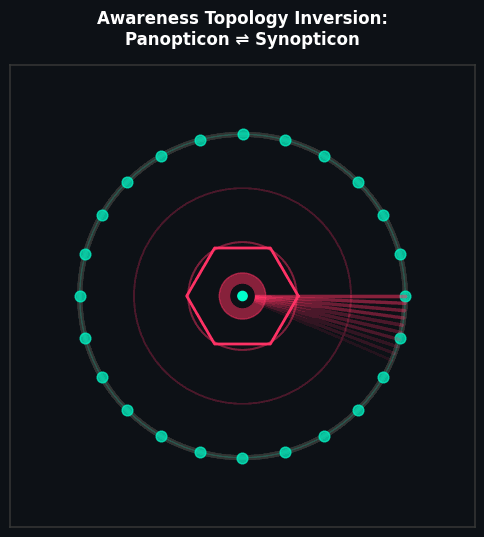

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from IPython.display import display, HTML
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# Configuration & Theme
# ---------------------------------------------------------
FRAMES = 90
FPS = 30
BG_COLOR = "#0d1117"  # GitHub Dark
ACCENT_1 = "#00ffcc"  # Cyan (Passive Nodes / Data)
ACCENT_2 = "#ff3366"  # Red (Panopticon Centralization)
ACCENT_3 = "#b055ff"  # Purple (Synopticon Mass-Network / Attention)
ACCENT_GOLD = "#ffcc00" # Gold (Focus / Convergence)

# Set global Seaborn dark theme
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": BG_COLOR,
    "axes.edgecolor": "#333333",
    "grid.color": "#222222",
    "text.color": "#e0e0e0",
    "xtick.color": "#e0e0e0",
    "ytick.color": "#e0e0e0"
})

def fig_to_image(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=100)
    buf.seek(0)
    return Image.open(buf).copy()

# ---------------------------------------------------------
# Visualizer: Panopticon ⇌ Synopticon
# ---------------------------------------------------------
def generate_awareness_inversion_gif(filename):
    print("Rendering Panopticon ⇌ Synopticon GIF...")
    frames = []

    N_NODES = 24
    R = 3.5

    fig, ax = plt.subplots(figsize=(6, 6))

    for i in range(FRAMES):
        ax.clear()
        t = i / FRAMES # 0.0 to 1.0

        # Power dynamic weights (Smooth cosine interpolation)
        # t=0, t=1: Panopticon=1.0 (Center watches Many)
        # t=0.5: Synopticon=1.0 (Many watch Center)
        pan_weight = (np.cos(t * 2 * np.pi) + 1) / 2
        syn_weight = 1.0 - pan_weight

        # Subtle rotation of the outer ring for seamless looping
        theta_base = np.linspace(0, 2 * np.pi, N_NODES, endpoint=False)
        theta = theta_base + (t * 2 * np.pi / N_NODES)
        xs = R * np.cos(theta)
        ys = R * np.sin(theta)

        # --- 1. BASE STRUCTURE ---
        # Outer boundary ring (the prison/platform)
        ax.add_patch(plt.Circle((0, 0), R, color="#333333", fill=False, linewidth=4, zorder=0))
        ax.add_patch(plt.Circle((0, 0), R, color=ACCENT_1, fill=False, linewidth=1, alpha=0.2, zorder=0))

        # --- 2. PANOPTICON STATE (Dispersion at the Center) ---
        if pan_weight > 0.01:
            # The Central Tower Base
            tower_poly = plt.Polygon(
                [[1.2 * pan_weight * np.cos(a), 1.2 * pan_weight * np.sin(a)] for a in np.linspace(0, 2*np.pi, 7)],
                color="#111111", zorder=1
            )
            ax.add_patch(tower_poly)
            ax.plot([1.2 * pan_weight * np.cos(a) for a in np.linspace(0, 2*np.pi, 7)],
                    [1.2 * pan_weight * np.sin(a) for a in np.linspace(0, 2*np.pi, 7)],
                    color=ACCENT_2, linewidth=2, alpha=pan_weight, zorder=2)

            # Expanding Radar Waves (Oppressive presence)
            for k in range(3):
                r_radar = R * ((t * 2 + k/3) % 1.0)
                alpha_radar = pan_weight * (1 - r_radar/R) * 0.7
                ax.add_patch(plt.Circle((0, 0), r_radar, color=ACCENT_2, fill=False, linewidth=1.5, alpha=alpha_radar, zorder=2))

            # Sweeping Searchlight (Gaze directed outward)
            radar_angle = t * 4 * np.pi
            for sweep in np.linspace(0, 0.5, 12):
                ax.plot([0, R * np.cos(radar_angle - sweep)],
                        [0, R * np.sin(radar_angle - sweep)],
                        color=ACCENT_2, linewidth=2.5, alpha=pan_weight * (0.5 - sweep), zorder=5)

            # The "All-Seeing Eye" Core
            eye_radius = 0.5 * pan_weight
            ax.add_patch(plt.Circle((0, 0), eye_radius, color=ACCENT_2, alpha=0.5, zorder=6))
            ax.add_patch(plt.Circle((0, 0), eye_radius*0.5, color=BG_COLOR, alpha=1.0, zorder=7))
            ax.add_patch(plt.Circle((0, 0), eye_radius*0.2, color=ACCENT_1, alpha=1.0, zorder=8))

        # --- 3. SYNOPTICON STATE (Power in the Networked Mass) ---
        if syn_weight > 0.01:
            # Web of connections between the "many"
            for j in range(N_NODES):
                # Primary ring links
                nj = (j + 1) % N_NODES
                ax.plot([xs[j], xs[nj]], [ys[j], ys[nj]], color=ACCENT_3, linewidth=2, alpha=syn_weight * 0.8, zorder=2)

                # Skipping mesh links (forming the social graph)
                sj = (j + 3) % N_NODES
                ax.plot([xs[j], xs[sj]], [ys[j], ys[sj]], color=ACCENT_GOLD, linewidth=1, alpha=syn_weight * 0.5, zorder=2)

                # Attentional beams pointing inward toward the focal point
                ax.plot([xs[j], 0], [ys[j], 0], color=ACCENT_3, linewidth=1, alpha=syn_weight * 0.3, zorder=1)

                # Data/Scrutiny packets flowing INWARD to crush the center
                pulse_pos = 1 - ((t * 2 + j/N_NODES) % 1.0)
                px = xs[j] * pulse_pos
                py = ys[j] * pulse_pos
                ax.scatter([px], [py], color=ACCENT_GOLD, s=25 * syn_weight, alpha=syn_weight * 0.9, zorder=6)

            # Overwhelmed Core Convergence (The individual scrutinized by the mass)
            core_size = 0.8 * syn_weight
            for angle in np.linspace(0, np.pi, 8):
                dx = core_size * np.cos(angle + t*np.pi)
                dy = core_size * np.sin(angle + t*np.pi)
                ax.plot([-dx, dx], [-dy, dy], color=ACCENT_GOLD, linewidth=2, alpha=syn_weight, zorder=7)

            # Golden halos on outer nodes indicating they hold the attention/power
            ax.scatter(xs, ys, color=ACCENT_GOLD, s=300 * syn_weight, alpha=0.15 * syn_weight, zorder=2)

        # --- 4. THE INDIVIDUAL NODES ---
        # Dormant/Passive individual nodes (Watched state)
        ax.scatter(xs, ys, color=ACCENT_1, s=30 + 30 * pan_weight, alpha=0.4 + 0.3 * pan_weight, zorder=3)
        # Awakened/Active networked nodes (Watching state)
        ax.scatter(xs, ys, color=ACCENT_3, s=60 + 120 * syn_weight, alpha=syn_weight * 0.9, edgecolors="white", linewidths=0.5, zorder=4)

        # --- 5. FORMATTING ---
        ax.set_xlim(-5, 5)
        ax.set_ylim(-5, 5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title("Awareness Topology Inversion:\nPanopticon ⇌ Synopticon", color="#ffffff", pad=15, fontweight='bold', fontsize=12)

        frames.append(fig_to_image(fig))

    plt.close(fig)
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=int(1000/FPS), loop=0)
    return filename

# ---------------------------------------------------------
# Execution & HTML Display
# ---------------------------------------------------------
file_awareness = generate_awareness_inversion_gif('panopticon_synopticon.gif')

def image_to_base64(filepath):
    with open(filepath, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

b64_awareness = image_to_base64(file_awareness)

print("Displaying Awareness Topology Loop...")

html_code = f"""
<div style="display: flex; flex-direction: column; align-items: center; justify-content: center; font-family: 'Courier New', monospace; color: white; background-color: #0d1117; padding: 30px; border-radius: 12px;">
    <div style="text-align: center; width: 80%; max-width: 600px;">
        <h2 style="color: #ffcc00; font-size: 18px; margin-bottom: 5px; text-transform: uppercase;">Topological Awareness Dispersion </h2>

        <div style="display: flex; justify-content: space-between; font-size: 11px; margin-bottom: 15px;">
            <div style="width: 48%; text-align: left; border-left: 2px solid #ff3366; padding-left: 10px;">
                <span style="color: #ff3366; font-weight: bold;">[ STATE: PANOPTICON ]</span><br>
                <span style="color: #888;">Centralization. The solitary eye directs its sweeping gaze outward, observing isolated, unconnected cells. Power belongs to the few watching the many.</span>
            </div>
            <div style="width: 48%; text-align: right; border-right: 2px solid #b055ff; padding-right: 10px;">
                <span style="color: #b055ff; font-weight: bold;">[ STATE: SYNOPTICON ]</span><br>
                <span style="color: #888;">Decentralization. The periphery awakens, linking into a dense social mesh. The mass directs a crushing collective gaze inward. Power belongs to the many watching the few.</span>
            </div>
        </div>

        <img src="data:image/gif;base64,{b64_awareness}" style="border: 1px solid #333; border-radius: 8px; width: 100%; box-shadow: 0 0 20px rgba(0,0,0,0.5);">

        <p style="font-size: 11px; color: #555; margin-top: 15px;">
            Smooth transition mapping `cos(t)` dynamics to power structures, gaze directionality, and network graph visibility.
        </p>
    </div>
</div>
"""

display(HTML(html_code))